### config.pq under configuration

In [5]:
path0 = "/user/home/il22158/work/vEcoli/out/gene_knockout_test3/configuration/experiment_id=gene_knockout_test3/variant=0/lineage_seed=0/generation=1/agent_id=0"

import pandas as pd

# Or read all parquet files from a directory
df0 = pd.read_parquet(f"{path0}/config.pq")
print(df0)

         experiment_id  suffix_time description  progress_bar sim_data_path  \
0  gene_knockout_test3        False                      True     0.cPickle   

   emitter           emitter_arg__out_dir  emit_topology  emit_processes  \
0  parquet  /user/work/il22158/vEcoli/out          False           False   

   emit_config  ...  \
0        False  ...   

   output_metadata__listeners__rna_synth_prob__target_rna_synth_prob_per_cistron  \
0  [EG10001, EG10002, EG10003, EG10004, EG10006, ...                               

   output_metadata__listeners__rna_synth_prob__expected_rna_init_per_cistron  \
0  [EG10001, EG10002, EG10003, EG10004, EG10006, ...                           

   output_metadata__listeners__rna_synth_prob__n_bound_TF_per_cistron  \
0  [EG10001, EG10002, EG10003, EG10004, EG10006, ...                    

   output_metadata__listeners__transcript_elongation_listener__count_rna_synthesized  \
0  [TU-8381[c], TU-8382[c], TU-8383[c], TU-8384[c...                        

### history - 20s time step

In [9]:
path = "/user/home/il22158/work/vEcoli/out/gene_knockout_test2/history/experiment_id=gene_knockout_test2/variant=0/lineage_seed=0/generation=1/agent_id=0"

import pandas as pd

# Or read all parquet files from a directory
df = pd.read_parquet(f"{path}/127.pq")
print(df)

                                                  bulk  \
0    [0, 0, 123, 0, 0, 0, 0, 0, 0, 0, 0, 38, 1, 0, ...   
1    [0, 0, 123, 0, 0, 0, 0, 0, 0, 0, 0, 38, 1, 0, ...   
2    [0, 0, 123, 0, 0, 0, 0, 0, 0, 0, 0, 38, 1, 0, ...   
3    [0, 0, 123, 0, 0, 0, 0, 0, 0, 0, 0, 38, 1, 0, ...   
4    [0, 0, 123, 0, 0, 0, 0, 0, 0, 0, 0, 38, 1, 0, ...   
..                                                 ...   
122  [0, 0, 242, 0, 0, 0, 0, 0, 0, 0, 0, 91, 0, 0, ...   
123  [0, 0, 243, 0, 0, 0, 0, 0, 0, 0, 0, 91, 0, 0, ...   
124  [0, 0, 247, 0, 0, 0, 0, 0, 0, 0, 0, 91, 0, 0, ...   
125  [0, 0, 251, 0, 0, 0, 0, 0, 0, 0, 0, 91, 0, 0, ...   
126  [0, 0, 252, 0, 0, 0, 0, 0, 0, 0, 0, 91, 0, 0, ...   

                    listeners__rna_counts__mRNA_counts  \
0    [0, 0, 1, 0, 0, 0, 0, 4, 2, 1, 0, 1, 0, 0, 0, ...   
1    [0, 0, 1, 0, 0, 0, 0, 4, 2, 1, 0, 1, 0, 0, 0, ...   
2    [0, 0, 1, 0, 0, 0, 0, 5, 2, 1, 0, 0, 1, 0, 0, ...   
3    [0, 0, 1, 0, 2, 0, 0, 6, 1, 1, 0, 0, 1, 0, 0, ...   
4    [0, 0, 1

In [10]:
import pandas as pd
import ast
import numpy as np

# Reuse df0 from previous cell
path_history = path0.replace('/configuration/', '/history/')
df_history = pd.read_parquet(f"{path_history}/127.pq")

print("=== Matching Config Metadata with History Data ===\n")

# Get metadata columns
metadata_cols = [col for col in df0.columns if col.startswith('output_metadata__')]

for col in metadata_cols:
    category_path = col.replace('output_metadata__', '')
    value = df0[col].iloc[0]
    
    # Parse if string
    if isinstance(value, str):
        try:
            value = ast.literal_eval(value)
        except:
            pass
    
    # Find matching history column (exact match, not prefix)
    if category_path in df_history.columns:
        history_col = category_path
        history_data = df_history[history_col]
        
        print(f"\n{category_path}:")
        
        # Handle both lists and numpy arrays
        if isinstance(value, (list, np.ndarray)):
            print(f"  Number of subcategories: {len(value)}")
            print(f"  Sample subcategory names (first 3): {value[:3].tolist() if isinstance(value, np.ndarray) else value[:3]}")
        else:
            print(f"  Number of subcategories: N/A (not a list)")
        
        print(f"  History column: Found")
        print(f"  History shape: {len(df_history)} timesteps")
        
        # Show sample data
        sample_timestep = history_data.iloc[0]
        if isinstance(sample_timestep, (list, np.ndarray)):
            sample_vals = sample_timestep[:3].tolist() if isinstance(sample_timestep, np.ndarray) else sample_timestep[:3]
            print(f"  Array length at t=0: {len(sample_timestep)}")
            print(f"  Sample values at t=0 (first 3): {sample_vals}")
    else:
        print(f"\n{category_path}:")
        if isinstance(value, (list, np.ndarray)):
            print(f"  Number of subcategories: {len(value)}")
            print(f"  Sample subcategory names (first 3): {value[:3].tolist() if isinstance(value, np.ndarray) else value[:3]}")
        else:
            print(f"  Number of subcategories: N/A (not a list)")
        print(f"  ⚠ No matching column in history!")

=== Matching Config Metadata with History Data ===


listeners__rna_counts__mRNA_counts:
  Number of subcategories: 3134
  Sample subcategory names (first 3): ['TU-8381[c]', 'TU-8382[c]', 'TU-8383[c]']
  History column: Found
  History shape: 127 timesteps
  Array length at t=0: 3134
  Sample values at t=0 (first 3): [0, 0, 1]

listeners__rna_counts__full_mRNA_counts:
  Number of subcategories: 3134
  Sample subcategory names (first 3): ['TU-8381[c]', 'TU-8382[c]', 'TU-8383[c]']
  History column: Found
  History shape: 127 timesteps
  Array length at t=0: 3134
  Sample values at t=0 (first 3): [0, 0, 1]

listeners__rna_counts__partial_mRNA_counts:
  Number of subcategories: 3134
  Sample subcategory names (first 3): ['TU-8381[c]', 'TU-8382[c]', 'TU-8383[c]']
  History column: Found
  History shape: 127 timesteps
  Array length at t=0: 3134
  Sample values at t=0 (first 3): [0, 0, 0]

listeners__rna_counts__mRNA_cistron_counts:
  Number of subcategories: 4345
  Sample subcategory names 

In [11]:
import pandas as pd
import numpy as np

# Get bulk metadata
bulk_metadata = df0['output_metadata__bulk'].iloc[0]

if isinstance(bulk_metadata, np.ndarray):
    bulk_names = bulk_metadata.tolist()
else:
    bulk_names = bulk_metadata

# Search for 'grow' (case-insensitive)
grow_matches = [name for name in bulk_names if 'grow' in name.lower()]

print(f"Found {len(grow_matches)} subcategories containing 'grow':")
for i, name in enumerate(grow_matches, 1):
    position = bulk_names.index(name)
    print(f"{i}. '{name}' at index {position}")

Found 0 subcategories containing 'grow':


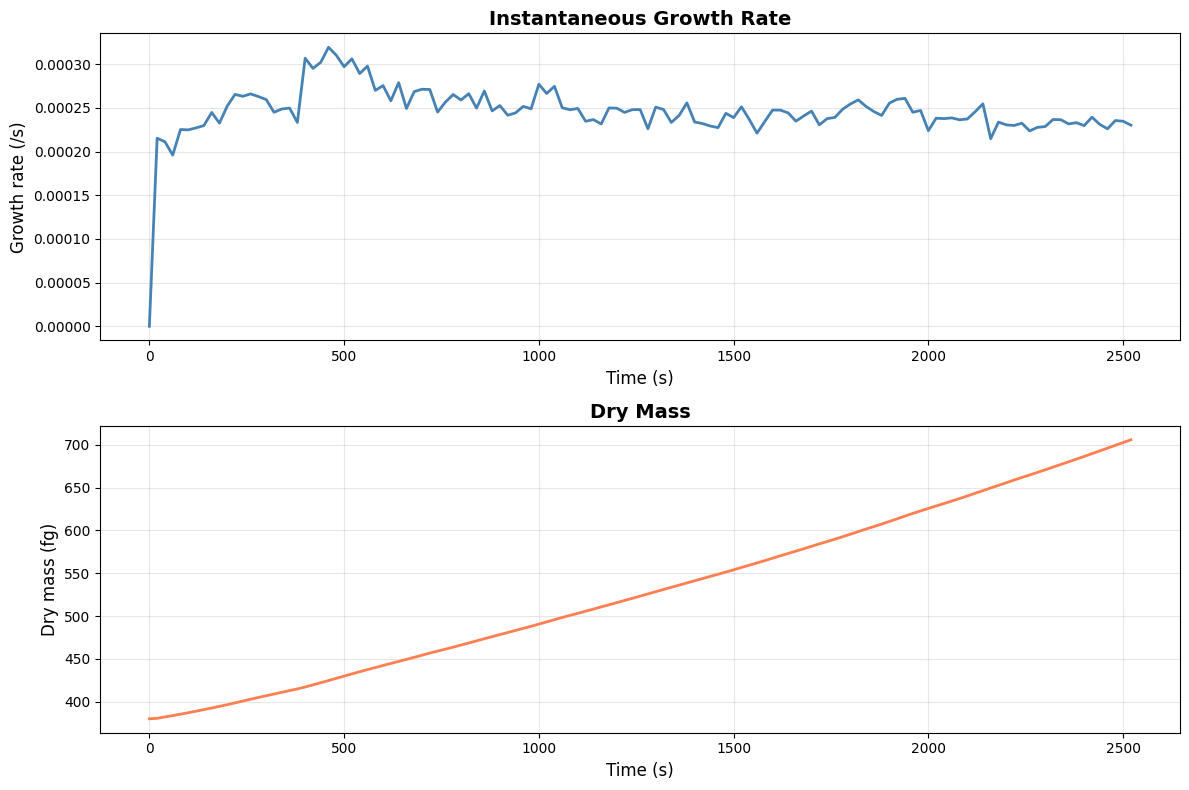

Simulation duration: 2540 seconds
Growth rate: mean=0.000246 /s, std=0.000030 /s
Dry mass: mean=528.96 fg, std=95.78 fg


In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Extract growth rate and dry mass
growth_rate = df_history['listeners__mass__instantaneous_growth_rate'].values
dry_mass = df_history['listeners__mass__dry_mass'].values

# Time in seconds (20 sec per timestep)
time_sec = np.arange(len(growth_rate)) * 20

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Growth rate
ax1.plot(time_sec, growth_rate, linewidth=2, color='steelblue')
ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel('Growth rate (/s)', fontsize=12)
ax1.set_title('Instantaneous Growth Rate', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Dry mass
ax2.plot(time_sec, dry_mass, linewidth=2, color='coral')
ax2.set_xlabel('Time (s)', fontsize=12)
ax2.set_ylabel('Dry mass (fg)', fontsize=12)
ax2.set_title('Dry Mass', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print(f"Simulation duration: {len(time_sec)*20} seconds")
print(f"Growth rate: mean={np.mean(growth_rate):.6f} /s, std={np.std(growth_rate):.6f} /s")
print(f"Dry mass: mean={np.mean(dry_mass):.2f} fg, std={np.std(dry_mass):.2f} fg")

=== Variant Metadata ===
condition: {'0': 'baseline', '1': {'condition': 'with_aa'}, '2': {'condition': 'acetate'}, '3': {'condition': 'succinate'}, '4': {'condition': 'no_oxygen'}}

Found 1 parquet files: ['127.pq']



Total timesteps: 127
Time range: 0.0 to 2520.0 seconds


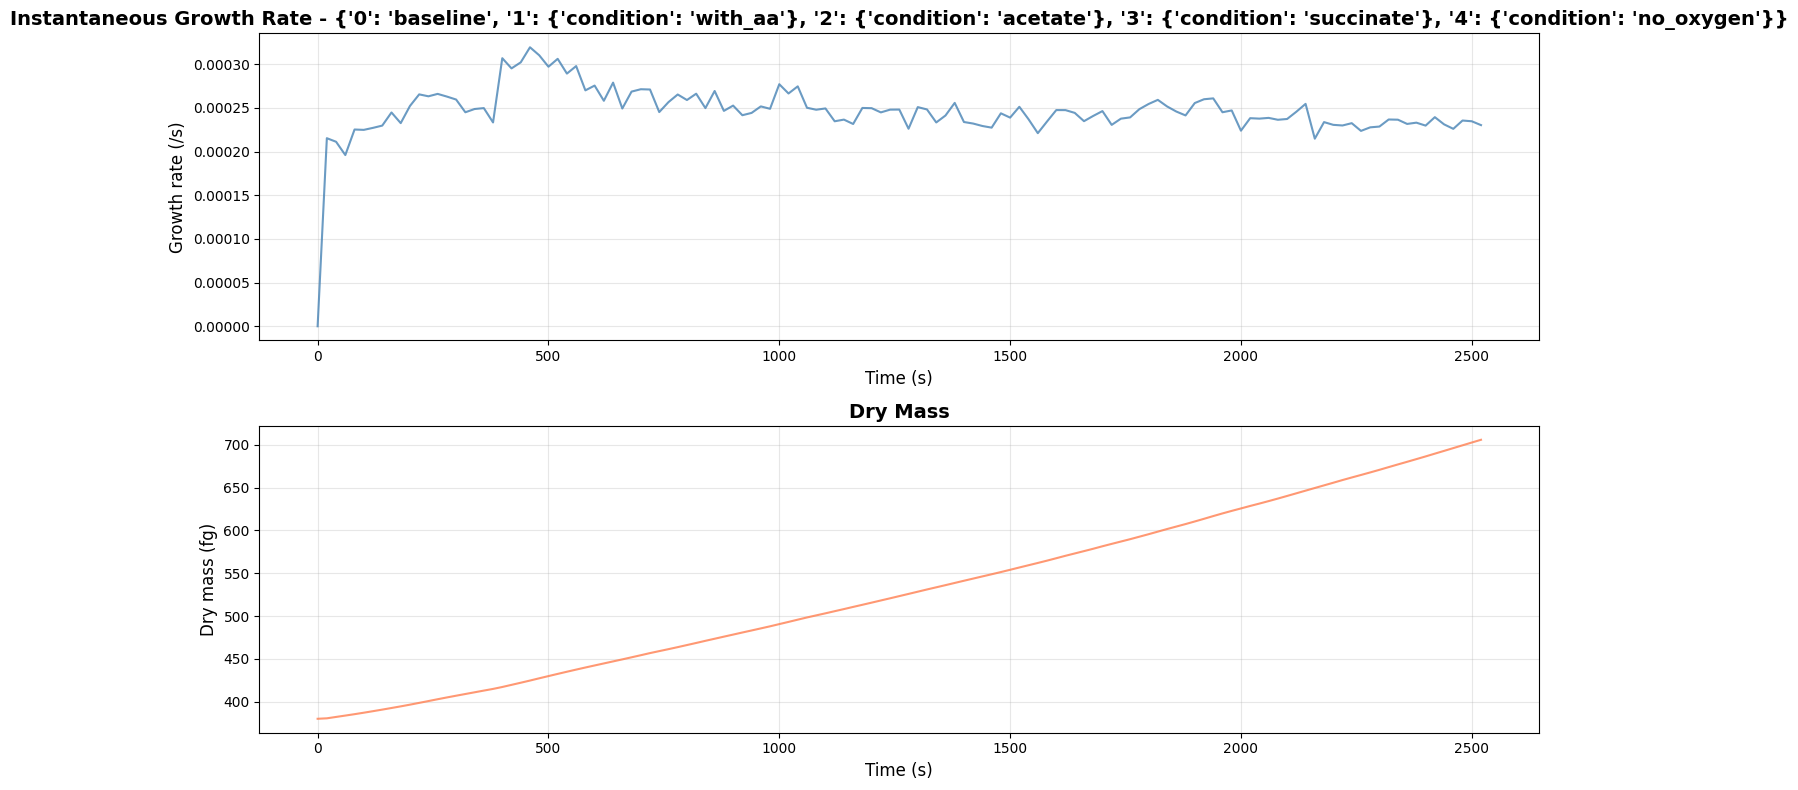


=== Statistics ===
Simulation duration: 2540 seconds (42.3 min)
Growth rate: mean=0.000246 /s, std=0.000030 /s
Dry mass: initial=379.95 fg, final=705.94 fg
Dry mass fold change: 1.86x


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import json
import glob

# Read variant metadata
metadata_path = "/user/home/il22158/work/vEcoli/out/all_media_conditions1/variant_sim_data/metadata.json"
with open(metadata_path, 'r') as f:
    variant_metadata = json.load(f)

print("=== Variant Metadata ===")
for key, value in variant_metadata.items():
    print(f"{key}: {value}")

# Find all parquet files in history folder
history_folder = path0.replace('/configuration/', '/history/')
pq_files = sorted(glob.glob(f"{history_folder}/*.pq"))
print(f"\nFound {len(pq_files)} parquet files: {[f.split('/')[-1] for f in pq_files]}")

# Read all files and concatenate
all_data = []
for pq_file in pq_files:
    df_temp = pd.read_parquet(pq_file)
    all_data.append(df_temp)
    
df_all = pd.concat(all_data, ignore_index=True)

# Sort by time column to ensure proper sequence
df_all = df_all.sort_values('time').reset_index(drop=True)
print(f"\nTotal timesteps: {len(df_all)}")
print(f"Time range: {df_all['time'].min()} to {df_all['time'].max()} seconds")

# Extract growth rate and dry mass
growth_rate = df_all['listeners__mass__instantaneous_growth_rate'].values
dry_mass = df_all['listeners__mass__dry_mass'].values
time_sec = np.arange(len(growth_rate)) * 20

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Growth rate
ax1.plot(time_sec, growth_rate, linewidth=1.5, color='steelblue', alpha=0.8)
ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel('Growth rate (/s)', fontsize=12)
ax1.set_title(f'Instantaneous Growth Rate - {variant_metadata.get("condition", "Unknown")}', 
              fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Dry mass
ax2.plot(time_sec, dry_mass, linewidth=1.5, color='coral', alpha=0.8)
ax2.set_xlabel('Time (s)', fontsize=12)
ax2.set_ylabel('Dry mass (fg)', fontsize=12)
ax2.set_title('Dry Mass', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print(f"\n=== Statistics ===")
print(f"Simulation duration: {len(time_sec)*20} seconds ({len(time_sec)*20/60:.1f} min)")
print(f"Growth rate: mean={np.mean(growth_rate):.6f} /s, std={np.std(growth_rate):.6f} /s")
print(f"Dry mass: initial={dry_mass[0]:.2f} fg, final={dry_mass[-1]:.2f} fg")
print(f"Dry mass fold change: {dry_mass[-1]/dry_mass[0]:.2f}x")

Variant 0: 1 files


Variant 1: 1 files


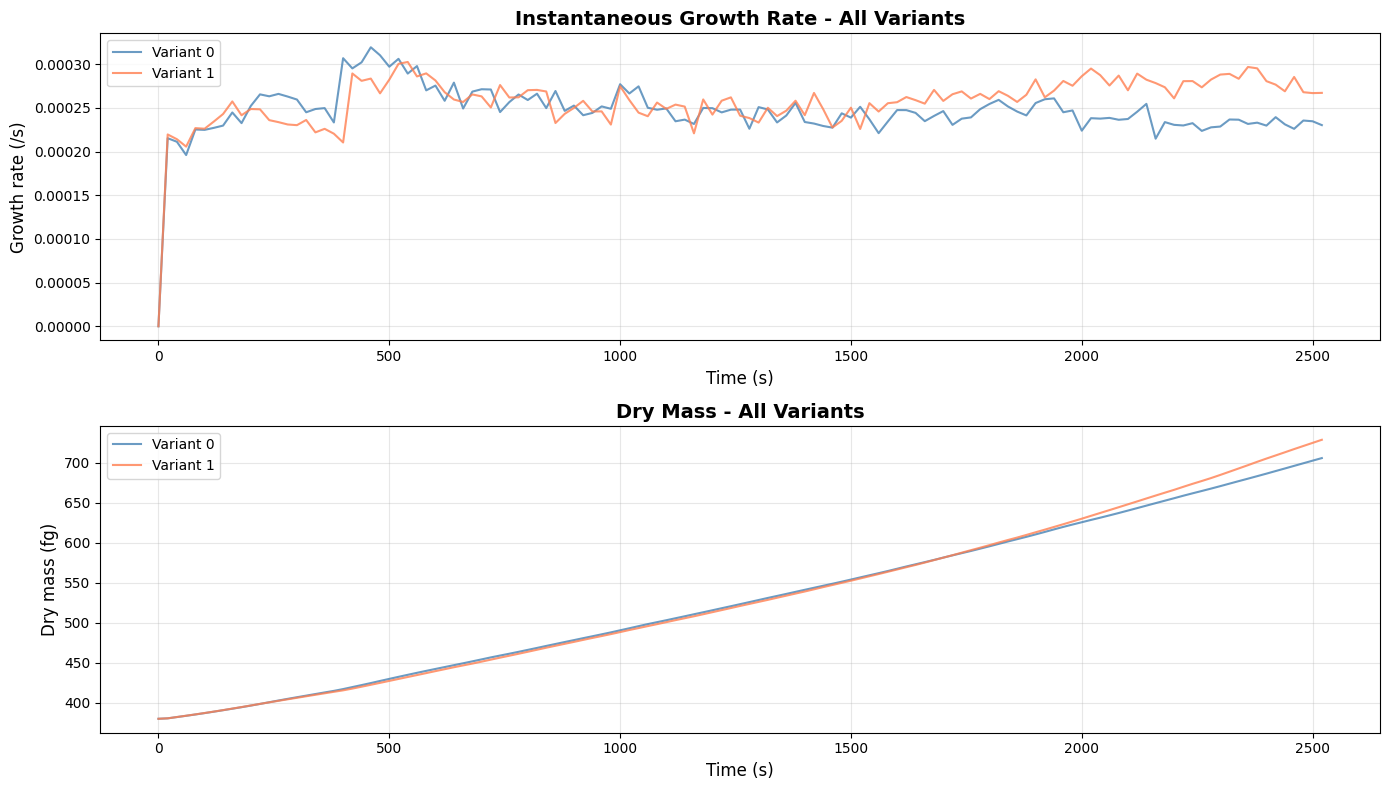


=== Statistics by Variant ===

Variant 0:
  Duration: 2540 s (42.3 min)
  Growth rate: mean=0.000246 /s
  Dry mass: 380.0 → 705.9 fg (1.86x)

Variant 1:
  Duration: 2540 s (42.3 min)
  Growth rate: mean=0.000257 /s
  Dry mass: 380.0 → 728.8 fg (1.92x)


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import glob

# Set base path for test simulation
base_path = "/user/home/il22158/work/vEcoli/out/gene_knockout_test3/history/experiment_id=gene_knockout_test3/variant=0/lineage_seed=0/generation=1/agent_id=0"

# Only 2 variants and 1 generation
all_variants = {}
for variant_id in range(2):
    # Update path for each variant
    history_folder = base_path.replace('/variant=0/', f'/variant={variant_id}/')
    pq_files = sorted(glob.glob(f"{history_folder}/*.pq"))
    
    if len(pq_files) == 0:
        print(f"No files found for variant {variant_id}")
        continue
    
    print(f"Variant {variant_id}: {len(pq_files)} files")
    
    # Read all files and concatenate
    all_data = []
    for pq_file in pq_files:
        df_temp = pd.read_parquet(pq_file)
        all_data.append(df_temp)
    
    df_variant = pd.concat(all_data, ignore_index=True)
    df_variant = df_variant.sort_values('time').reset_index(drop=True)
    
    all_variants[variant_id] = {
        'time': np.arange(len(df_variant)) * 20,
        'growth_rate': df_variant['listeners__mass__instantaneous_growth_rate'].values,
        'dry_mass': df_variant['listeners__mass__dry_mass'].values
    }

# Plot all variants
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

colors = ['steelblue', 'coral']
for variant_id, data in all_variants.items():
    label = f'Variant {variant_id}'
    
    # Growth rate
    ax1.plot(data['time'], data['growth_rate'], 
             linewidth=1.5, color=colors[variant_id], alpha=0.8, label=label)
    
    # Dry mass
    ax2.plot(data['time'], data['dry_mass'], 
             linewidth=1.5, color=colors[variant_id], alpha=0.8, label=label)

# Format growth rate plot
ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel('Growth rate (/s)', fontsize=12)
ax1.set_title('Instantaneous Growth Rate - All Variants', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)

# Format dry mass plot
ax2.set_xlabel('Time (s)', fontsize=12)
ax2.set_ylabel('Dry mass (fg)', fontsize=12)
ax2.set_title('Dry Mass - All Variants', fontsize=14, fontweight='bold')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics for each variant
print("\n=== Statistics by Variant ===")
for variant_id, data in all_variants.items():
    print(f"\nVariant {variant_id}:")
    print(f"  Duration: {len(data['time'])*20} s ({len(data['time'])*20/60:.1f} min)")
    print(f"  Growth rate: mean={np.mean(data['growth_rate']):.6f} /s")
    print(f"  Dry mass: {data['dry_mass'][0]:.1f} → {data['dry_mass'][-1]:.1f} fg ({data['dry_mass'][-1]/data['dry_mass'][0]:.2f}x)")

Variant 0: 1 files


Variant 1: 1 files


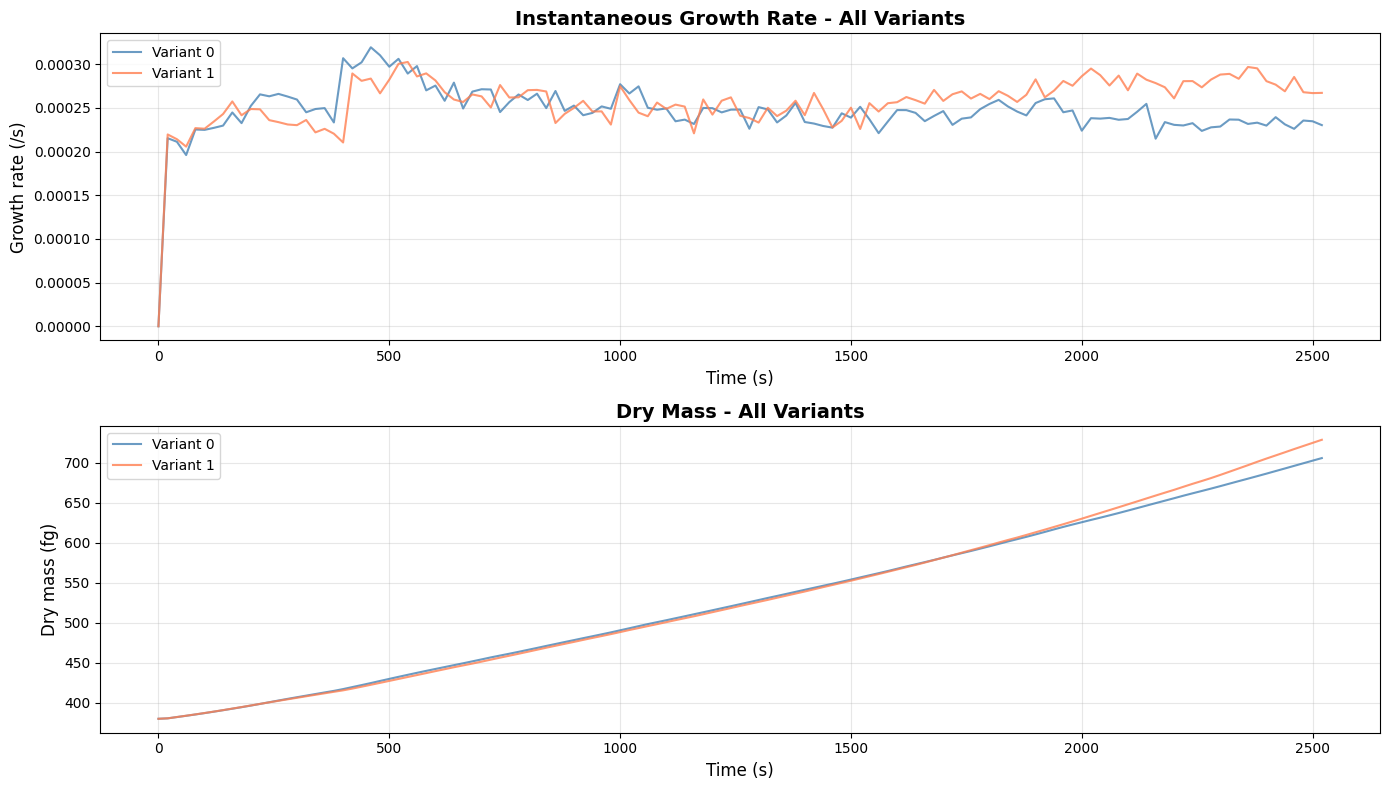


=== Statistics by Variant ===

Variant 0:
  Duration: 2540 s (42.3 min)
  Growth rate: mean=0.000246 /s
  Dry mass: 380.0 → 705.9 fg (1.86x)

Variant 1:
  Duration: 2540 s (42.3 min)
  Growth rate: mean=0.000257 /s
  Dry mass: 380.0 → 728.8 fg (1.92x)


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import glob

# Set base path for test simulation
base_path = "/user/home/il22158/work/vEcoli/out/gene_knockout_test3/history/experiment_id=gene_knockout_test3/variant=0/lineage_seed=0/generation=1/agent_id=0"

# Only 2 variants and 1 generation
all_variants = {}
for variant_id in range(2):
    # Update path for each variant
    history_folder = base_path.replace('/variant=0/', f'/variant={variant_id}/')
    pq_files = sorted(glob.glob(f"{history_folder}/*.pq"))
    
    if len(pq_files) == 0:
        print(f"No files found for variant {variant_id}")
        continue
    
    print(f"Variant {variant_id}: {len(pq_files)} files")
    
    # Read all files and concatenate
    all_data = []
    for pq_file in pq_files:
        df_temp = pd.read_parquet(pq_file)
        all_data.append(df_temp)
    
    df_variant = pd.concat(all_data, ignore_index=True)
    df_variant = df_variant.sort_values('time').reset_index(drop=True)
    
    all_variants[variant_id] = {
        'time': np.arange(len(df_variant)) * 20,
        'growth_rate': df_variant['listeners__mass__instantaneous_growth_rate'].values,
        'dry_mass': df_variant['listeners__mass__dry_mass'].values
    }

# Plot all variants
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

colors = ['steelblue', 'coral']
for variant_id, data in all_variants.items():
    label = f'Variant {variant_id}'
    
    # Growth rate
    ax1.plot(data['time'], data['growth_rate'], 
             linewidth=1.5, color=colors[variant_id], alpha=0.8, label=label)
    
    # Dry mass
    ax2.plot(data['time'], data['dry_mass'], 
             linewidth=1.5, color=colors[variant_id], alpha=0.8, label=label)

# Format growth rate plot
ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel('Growth rate (/s)', fontsize=12)
ax1.set_title('Instantaneous Growth Rate - All Variants', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)

# Format dry mass plot
ax2.set_xlabel('Time (s)', fontsize=12)
ax2.set_ylabel('Dry mass (fg)', fontsize=12)
ax2.set_title('Dry Mass - All Variants', fontsize=14, fontweight='bold')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics for each variant
print("\n=== Statistics by Variant ===")
for variant_id, data in all_variants.items():
    print(f"\nVariant {variant_id}:")
    print(f"  Duration: {len(data['time'])*20} s ({len(data['time'])*20/60:.1f} min)")
    print(f"  Growth rate: mean={np.mean(data['growth_rate']):.6f} /s")
    print(f"  Dry mass: {data['dry_mass'][0]:.1f} → {data['dry_mass'][-1]:.1f} fg ({data['dry_mass'][-1]/data['dry_mass'][0]:.2f}x)")